# Étape 2 - Diagnostic qualité et EDA analytique

Cette étape se déroule en deux temps.

**Partie A : diagnostic qualité.** Les cinq dimensions attendues (complétude, unicité,
cohérence, exactitude, fraîcheur) sont analysées une par une, puis les problèmes trouvés
sont priorisés dans un rapport unique qui sert de cahier des charges à l'étape 3.

**Partie B : EDA analytique.** Les cinq questions business formulées au cadrage reçoivent
une réponse chiffrée et illustrée, et la relation entre les variables et la cible est
mesurée pour formuler des hypothèses sur ce que le modèle devrait apprendre.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / 'csv' / 'dataset_phase1_modelisation.csv'
ANALYTIC_PATH = PROJECT_PATH / 'csv' / 'dataset_phase1_analytique.csv'
FIGURE_PATH = PROJECT_PATH / 'figures_eda'
FIGURE_PATH.mkdir(exist_ok=True)

TARGET = "6-Taux d'emploi salarié en France - 6 mois après le diplôme"
SORTANTS = '6-Nombre de sortants - 6 mois après le diplôme'
POURSUIVANTS = '6-Nombre de poursuivants - 6 mois après le diplôme'
NB_STABLE = '6-Nombre de sortants en emploi stable - 6 mois après le diplôme'
TX_STABLE = '6-Taux de sortants en emploi stable - 6 mois après le diplôme'
NB_NON_SALARIE = '6-Nombre de sortants en emploi non salarié - 6 mois après le diplôme'
TX_NON_SALARIE = '6-Taux de sortants en emploi non salarié - 6 mois après le diplôme'
HORIZONS = [f"{mois}-Taux d'emploi salarié en France - {mois} mois après le diplôme"
            for mois in (12, 18, 24, 30)]
CODE_UAI = "Code UAI de l'établissement"
CODE_SISE = 'Code du diplôme SISE'

# Charte graphique commune à toutes les figures du projet.
COULEUR = '#2f6f9f'
COULEUR_ALT = '#d1793c'
COULEUR_NEUTRE = '#9aa5ad'
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'font.size': 9,
})


SOURCE_DONNEES = ('Source : InserSup, millésime 2026_S1 · promotions 2019 à 2024 · '
                  'MESR, Licence Ouverte Etalab')


def annoter_source(texte=SOURCE_DONNEES):
    """Appose la source et la période en pied de figure, juste avant l'export.

    Une figure finit toujours par circuler seule, détachée du notebook : elle doit
    porter d'où viennent ses chiffres.
    """
    plt.gcf().text(0.995, -0.012, texte, ha='right', va='top',
                   fontsize=7, color='#9aa5ad', style='italic')

df = pd.read_csv(DATA_PATH)
print('Dimensions :', df.shape)
df.info()

Dimensions : (17065, 23)
<class 'pandas.DataFrame'>
RangeIndex: 17065 entries, 0 to 17064
Data columns (total 23 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Région                                                                17065 non-null  str    
 1   Académie                                                              17065 non-null  str    
 2   Établissement                                                         17065 non-null  str    
 3   Type de diplôme                                                       17065 non-null  str    
 4   Domaine disciplinaire                                                 17065 non-null  str    
 5   Discipline                                                            17065 non-null  str    
 6   Secteur disciplinaire                                                 17065 non-

# Partie A - Diagnostic qualité

## A1. Complétude

La complétude mesure la part de valeurs réellement renseignées. La règle appliquée est
simple : **la cible doit être complète**, sinon la ligne n'est pas exploitable pour une
régression ; les autres colonnes peuvent tolérer des trous à condition de savoir
pourquoi ils existent.

In [2]:
completude = pd.DataFrame({
    'valeurs_renseignees': df.notna().sum(),
    'valeurs_manquantes': df.isna().sum(),
})
completude['taux_remplissage_%'] = (100 * completude['valeurs_renseignees'] / len(df)).round(2)
completude = completude.sort_values('taux_remplissage_%')

print('Cible complète :', df[TARGET].notna().all())
print('Colonnes totalement complètes :', int((completude['valeurs_manquantes'] == 0).sum()),
      'sur', len(completude))
completude[completude['valeurs_manquantes'] > 0]

Cible complète : True
Colonnes totalement complètes : 21 sur 23


,valeurs_renseignees,valeurs_manquantes,taux_remplissage_%
30-Taux d'emploi salarié en France - 30 mois après le diplôme,14123,2942,82.76
24-Taux d'emploi salarié en France - 24 mois après le diplôme,14123,2942,82.76


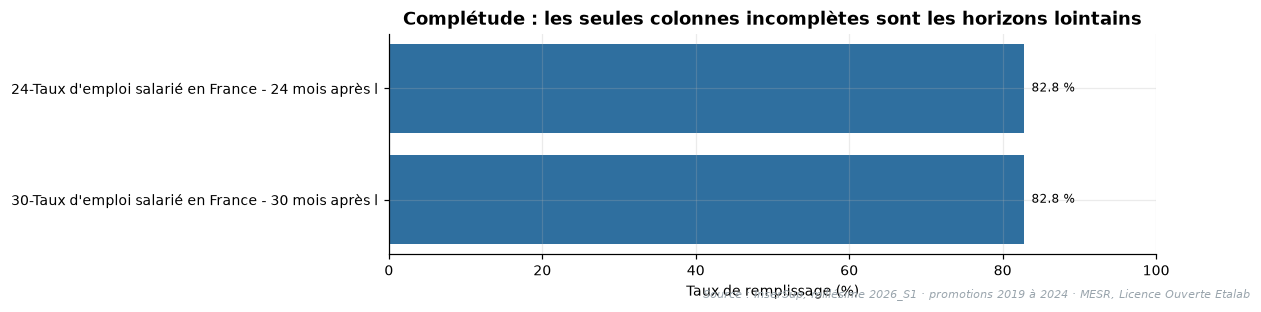

In [3]:
incomplets = completude[completude['valeurs_manquantes'] > 0]

figure, axes = plt.subplots(figsize=(9, 2.6))
axes.barh(range(len(incomplets)), incomplets['taux_remplissage_%'], color=COULEUR)
axes.set_yticks(range(len(incomplets)))
axes.set_yticklabels([nom[:52] for nom in incomplets.index])
axes.set_xlim(0, 100)
axes.set_xlabel('Taux de remplissage (%)')
axes.set_title("Complétude : les seules colonnes incomplètes sont les horizons lointains")
for position, valeur in enumerate(incomplets['taux_remplissage_%']):
    axes.text(valeur + 1, position, f'{valeur:.1f} %', va='center', fontsize=8)
annoter_source()
plt.savefig(FIGURE_PATH / 'fig01_completude.png')
plt.show()

Les seules colonnes incomplètes sont les taux d'emploi à 24 et 30 mois. Le trou n'est pas
aléatoire : il correspond aux promotions trop récentes pour avoir été suivies aussi
longtemps. C'est une **donnée pas encore observable**, pas une erreur de saisie, et ces
colonnes seront de toute façon exclues du modèle (voir A5 et la partie B).

## A2. Unicité

La question n'est pas seulement « y a-t-il des lignes identiques ? » mais « quelle
combinaison de colonnes identifie une ligne de façon unique ? ». On teste plusieurs clés
candidates par ordre croissant de précision.

In [4]:
DIMENSIONS_DIPLOME = ['Type de diplôme', 'Domaine disciplinaire', 'Discipline',
                      'Secteur disciplinaire', 'Libellé du diplôme']
CLE_CODES = [CODE_UAI, CODE_SISE, 'Promotion']

candidates = {
    'Nom établissement + libellé + promotion': ['Établissement', 'Libellé du diplôme',
                                                'Promotion'],
    'Clé métier complète, sur le nom établissement':
        ['Établissement'] + DIMENSIONS_DIPLOME + ['Promotion'],
    'Clé métier complète, sur le code UAI':
        [CODE_UAI] + DIMENSIONS_DIPLOME + ['Promotion'],
    'Code UAI + promotion': [CODE_UAI, 'Promotion'],
    'Code SISE + promotion': [CODE_SISE, 'Promotion'],
    'Code UAI + code SISE + promotion': CLE_CODES,
}

unicite = pd.DataFrame([
    {'clé candidate': nom,
     'colonnes': len(colonnes),
     'lignes en trop': int(df.duplicated(colonnes).sum()),
     'lignes impliquées': int(df.duplicated(colonnes, keep=False).sum()),
     'clé unique': not df.duplicated(colonnes).any()}
    for nom, colonnes in candidates.items()
])

print('Doublons de lignes complètes :', int(df.duplicated().sum()))
unicite

Doublons de lignes complètes : 0


,clé candidate,colonnes,lignes en trop,lignes impliquées,clé unique
0,Nom établissement + libellé + promotion,3,758,1487,False
1,"Clé métier complète, sur le nom établissement",7,144,261,False
2,"Clé métier complète, sur le code UAI",7,107,201,False
3,Code UAI + promotion,2,15285,16277,False
4,Code SISE + promotion,2,11371,13106,False
5,Code UAI + code SISE + promotion,3,0,0,True


In [5]:
# Pourquoi les libellés échouent : ce ne sont pas des identifiants, ni côté formation
# ni côté établissement.
homonymes_diplome = (df.groupby('Libellé du diplôme')[CODE_SISE].nunique()
                     .sort_values(ascending=False))
homonymes_etablissement = (df.groupby('Établissement')[CODE_UAI].nunique()
                           .sort_values(ascending=False))

nb_libelles = df['Libellé du diplôme'].nunique()
nb_sise = df[CODE_SISE].nunique()
nb_etablissements = df['Établissement'].nunique()
nb_uai = df[CODE_UAI].nunique()

print(f'Libellés de diplôme : {nb_libelles} libellés pour {nb_sise} codes SISE')
print(f"  dont {int((homonymes_diplome > 1).sum())} libellés portés par plusieurs codes, "
      f"jusqu'à {int(homonymes_diplome.max())} codes pour un même libellé")
print(f'Établissements : {nb_etablissements} noms pour {nb_uai} codes UAI')
print(f"  dont {int((homonymes_etablissement > 1).sum())} noms portés par plusieurs codes")
print()
print('Cinq libellés les plus ambigus :')
homonymes_diplome.head(5).to_frame('codes SISE distincts')

Libellés de diplôme : 1290 libellés pour 1408 codes SISE
  dont 91 libellés portés par plusieurs codes, jusqu'à 6 codes pour un même libellé
Établissements : 329 noms pour 365 codes UAI
  dont 29 noms portés par plusieurs codes

Cinq libellés les plus ambigus :


,codes SISE distincts
Libellé du diplôme,
SCIENCES HUMAINES ET SOCIALES : PSYCHOLOGIE,6
"SCIENCES, TECHNOLOGIES, SANTE : INFORMATIQUE",6
SCIENCES HUMAINES ET SOCIALES : INFORMATION ET COMMUNICATION,5
"DROIT, ECONOMIE, GESTION : MANAGEMENT",5
ECONOMIE-GESTION : SCIENCES DE GESTION,5


**Conclusion de la dimension unicité.** Il n'y a aucun doublon de ligne complète, mais
aucune clé fondée sur les libellés n'est unique. Le tableau se lit de haut en bas comme une
démonstration en trois temps.

D'abord, remplacer le **nom d'établissement** par son **code UAI**, à dimensions
identiques, fait tomber le nombre de conflits : une partie des collisions ne venait pas des
diplômes mais des établissements homonymes. Ensuite, même avec le code UAI, des conflits
subsistent : deux formations distinctes peuvent porter le même libellé de diplôme. Enfin,
remplacer le libellé par le **code SISE** les élimine tous.

Ni le code UAI ni le code SISE ne suffisent seuls : un établissement propose plusieurs
diplômes, un diplôme est proposé par plusieurs établissements, et une formation est publiée
sur six promotions. Chacune des trois colonnes de la clé est donc nécessaire.

Ces conflits ne sont pas des duplications à supprimer : ce sont des formations différentes
qui portent le même nom. C'est la raison pour laquelle les deux codes ont été ajoutés au
schéma d'extraction à l'étape 1. Le nettoyage de l'étape 3 n'aura donc **aucun doublon à
supprimer**, ce qui est un résultat, pas une omission.

## A3. Cohérence

La cohérence vérifie que les colonnes racontent la même histoire entre elles. Le fichier
publie à la fois des effectifs et des taux : chaque taux doit pouvoir se recalculer à
partir des effectifs. C'est le contrôle le plus discriminant du jeu.

In [6]:
# Le nombre de sortants en emploi salarié n'est pas publié à 6 mois : on le déduit du taux.
emploi_salarie_implicite = df[TARGET] / 100 * df[SORTANTS]

controles = {}
controles['taux dans [0, 100]'] = int(
    sum(((df[colonne] < 0) | (df[colonne] > 100)).sum()
        for colonne in df.columns if 'Taux' in colonne))
controles['effectifs négatifs'] = int(
    (df[[SORTANTS, POURSUIVANTS, NB_STABLE, NB_NON_SALARIE]] < 0).sum().sum())
controles['effectif sous le seuil de publication (20)'] = int((df[SORTANTS] < 20).sum())
controles['nb en emploi salarié non entier'] = int(
    (~np.isclose(emploi_salarie_implicite, emploi_salarie_implicite.round(), atol=0.01)).sum())

# taux d'emploi stable = nb en emploi stable / nb en emploi salarié
taux_stable_recalcule = 100 * df[NB_STABLE] / emploi_salarie_implicite.replace(0, np.nan)
ecart_stable = (taux_stable_recalcule - df[TX_STABLE]).abs()
controles['taux stable non reconstituable (écart > 0,05 pt)'] = int((ecart_stable > 0.05).sum())

# taux d'emploi non salarié = nb en emploi non salarié / nb de sortants
taux_non_salarie_recalcule = 100 * df[NB_NON_SALARIE] / df[SORTANTS]
controles['taux non salarié non reconstituable'] = int(
    (~np.isclose(taux_non_salarie_recalcule, df[TX_NON_SALARIE], atol=0.05)).sum())

# le nombre en emploi stable ne peut pas dépasser le nombre en emploi salarié
controles['emploi stable > emploi salarié'] = int(
    (df[NB_STABLE] > emploi_salarie_implicite + 0.5).sum())

diagnostic_coherence = pd.Series(controles, name='lignes en défaut').to_frame()
diagnostic_coherence['part_%'] = (100 * diagnostic_coherence['lignes en défaut'] / len(df)).round(2)
diagnostic_coherence

,lignes en défaut,part_%
"taux dans [0, 100]",0,0.00
effectifs négatifs,0,0.00
effectif sous le seuil de publication (20),0,0.00
nb en emploi salarié non entier,190,1.11
"taux stable non reconstituable (écart > 0,05 pt)",11,0.06
taux non salarié non reconstituable,0,0.00
emploi stable > emploi salarié,0,0.00


Deux résultats méritent un commentaire.

Les **190 lignes** où l'effectif en emploi salarié déduit du taux n'est pas un entier
viennent de l'arrondi du taux publié à deux décimales : sur une formation de 1 000
sortants, deux décimales ne suffisent pas à retrouver l'effectif exact. Ce n'est pas une
incohérence de la source.

Les **11 lignes** où le taux d'emploi stable ne se reconstitue pas à partir des effectifs
sont, elles, de vraies anomalies. Elles sont peu nombreuses mais réelles, et le nettoyage
de l'étape 3 devra trancher leur sort.

In [7]:
# Cohérence temporelle : l'insertion doit globalement progresser avec l'ancienneté.
progression = pd.DataFrame({
    'horizon': ['6 → 12 mois', '12 → 18 mois', '18 → 24 mois', '24 → 30 mois'],
    'observations comparables': [
        int((df[TARGET].notna() & df[HORIZONS[0]].notna()).sum()),
        int((df[HORIZONS[0]].notna() & df[HORIZONS[1]].notna()).sum()),
        int((df[HORIZONS[1]].notna() & df[HORIZONS[2]].notna()).sum()),
        int((df[HORIZONS[2]].notna() & df[HORIZONS[3]].notna()).sum()),
    ],
    'taux en baisse (%)': [
        round(100 * (df[HORIZONS[0]] < df[TARGET]).mean(), 1),
        round(100 * (df[HORIZONS[1]] < df[HORIZONS[0]]).mean(), 1),
        round(100 * (df[HORIZONS[2]] < df[HORIZONS[1]]).mean(), 1),
        round(100 * (df[HORIZONS[3]] < df[HORIZONS[2]]).mean(), 1),
    ],
    'gain moyen (points)': [
        round((df[HORIZONS[0]] - df[TARGET]).mean(), 2),
        round((df[HORIZONS[1]] - df[HORIZONS[0]]).mean(), 2),
        round((df[HORIZONS[2]] - df[HORIZONS[1]]).mean(), 2),
        round((df[HORIZONS[3]] - df[HORIZONS[2]]).mean(), 2),
    ],
})
progression

,horizon,observations comparables,taux en baisse (%),gain moyen (points)
0,6 → 12 mois,17065,11.0,9.75
1,12 → 18 mois,17065,33.1,1.38
2,18 → 24 mois,14123,20.2,2.88
3,24 → 30 mois,14123,40.3,-1.27


## A4. Exactitude

L'exactitude s'intéresse aux valeurs plausibles mais suspectes. Sur un taux borné entre 0
et 100, la règle de l'écart interquartile signale mécaniquement les queues de
distribution : il faut donc vérifier si les points signalés sont des erreurs ou des
formations réellement atypiques.

In [8]:
q1, q3 = df[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atypiques = df[(df[TARGET] < borne_basse) | (df[TARGET] > borne_haute)]

print(f'Bornes IQR : [{borne_basse:.2f} ; {borne_haute:.2f}]')
print(f'Observations atypiques : {len(atypiques)} '
      f'({100 * len(atypiques) / len(df):.2f} % du jeu)')
print(f'Cible exactement à 0 : {int((df[TARGET] == 0).sum())} lignes '
      f'| exactement à 100 : {int((df[TARGET] == 100).sum())} lignes')
print()
print("Effectif des formations atypiques comparé au reste du jeu :")
comparaison = pd.DataFrame({
    'atypiques': atypiques[SORTANTS].describe(),
    'reste du jeu': df.drop(atypiques.index)[SORTANTS].describe(),
}).round(1)
comparaison

Bornes IQR : [4.26 ; 108.22]
Observations atypiques : 31 (0.18 % du jeu)
Cible exactement à 0 : 15 lignes | exactement à 100 : 29 lignes

Effectif des formations atypiques comparé au reste du jeu :


,atypiques,reste du jeu
count,31.0,17034.0
mean,39.1,62.3
std,30.6,92.9
min,20.0,20.0
25%,24.0,26.0
50%,27.0,37.0
75%,40.5,62.0
max,171.0,1882.0


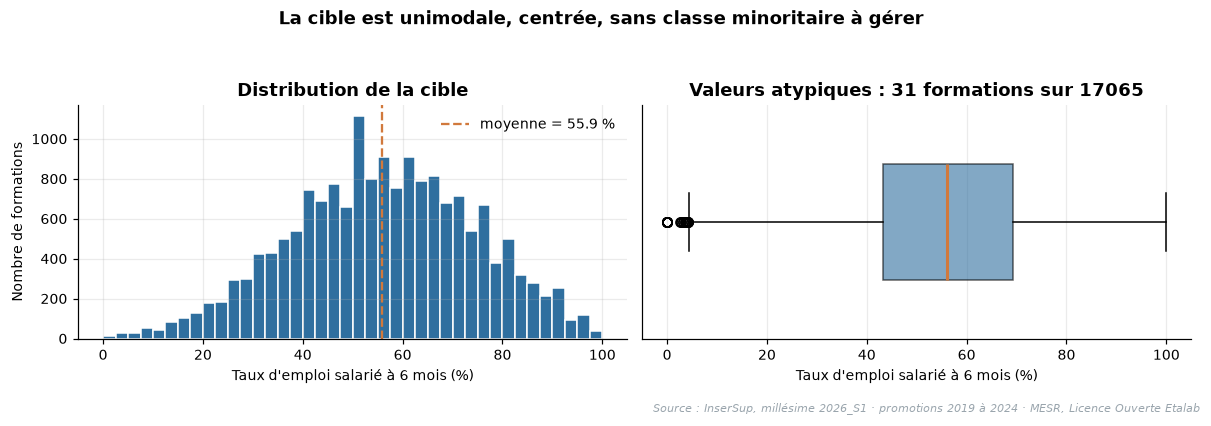

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(df[TARGET], bins=40, color=COULEUR, edgecolor='white')
axes[0].axvline(df[TARGET].mean(), color=COULEUR_ALT, linestyle='--',
                label=f"moyenne = {df[TARGET].mean():.1f} %")
axes[0].set_xlabel("Taux d'emploi salarié à 6 mois (%)")
axes[0].set_ylabel('Nombre de formations')
axes[0].set_title('Distribution de la cible')
axes[0].legend(frameon=False)

axes[1].boxplot(df[TARGET].dropna(), orientation='horizontal', widths=0.5,
                patch_artist=True,
                boxprops={'facecolor': COULEUR, 'alpha': 0.6},
                medianprops={'color': COULEUR_ALT, 'linewidth': 2})
axes[1].set_xlabel("Taux d'emploi salarié à 6 mois (%)")
axes[1].set_yticks([])
axes[1].set_title(f'Valeurs atypiques : {len(atypiques)} formations sur {len(df)}')

figure.suptitle('La cible est unimodale, centrée, sans classe minoritaire à gérer',
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.92))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig02_distribution_cible.png')
plt.show()

La borne haute calculée par la règle IQR vaut 108, au-delà du maximum possible : **seule
la queue basse est signalée**, 31 formations sur 17 065. Ces observations ne sont pas des
erreurs : leur effectif médian est de 27 sortants contre 37 pour le reste du jeu, et sur
un si petit effectif quelques diplômés suffisent à faire basculer le taux. Une formation
de 20 sortants dont aucun n'est en emploi salarié affiche légitimement 0 %.

**Elles sont conservées.** Les supprimer reviendrait à retirer du jeu précisément les cas
que le modèle aura du mal à prédire, et à surestimer sa performance réelle.

## A5. Fraîcheur

La fraîcheur mesure l'écart entre la date d'observation et la date d'usage, et vérifie
que toutes les périodes sont couvertes de la même façon. C'est ici que se révèle le
mécanisme des valeurs manquantes détectées en A1.

In [10]:
fraicheur = df.groupby('Promotion').agg(
    lignes=(TARGET, 'size'),
    cible_renseignee=(TARGET, 'count'),
    taux_12_mois=(HORIZONS[0], 'count'),
    taux_24_mois=(HORIZONS[2], 'count'),
    taux_30_mois=(HORIZONS[3], 'count'),
)
for colonne in ['cible_renseignee', 'taux_12_mois', 'taux_24_mois', 'taux_30_mois']:
    fraicheur[colonne] = (100 * fraicheur[colonne] / fraicheur['lignes']).round(1)

MILLESIME = 2026
fraicheur['ancienneté (années)'] = MILLESIME - fraicheur.index

print(f'Millésime de diffusion : 2026_S1')
print(f"Promotions couvertes : {df['Promotion'].min()} à {df['Promotion'].max()} "
      f"({df['Promotion'].nunique()} promotions)")
print('Colonnes exprimées en % de lignes renseignées :')
fraicheur

Millésime de diffusion : 2026_S1
Promotions couvertes : 2019 à 2024 (6 promotions)
Colonnes exprimées en % de lignes renseignées :


,lignes,cible_renseignee,taux_12_mois,taux_24_mois,taux_30_mois,ancienneté (années)
Promotion,,,,,,
2019,2657,100.0,100.0,100.0,100.0,7
2020,2710,100.0,100.0,100.0,100.0,6
2021,2933,100.0,100.0,100.0,100.0,5
2022,2958,100.0,100.0,100.0,100.0,4
2023,2865,100.0,100.0,100.0,100.0,3
2024,2942,100.0,100.0,0.0,0.0,2


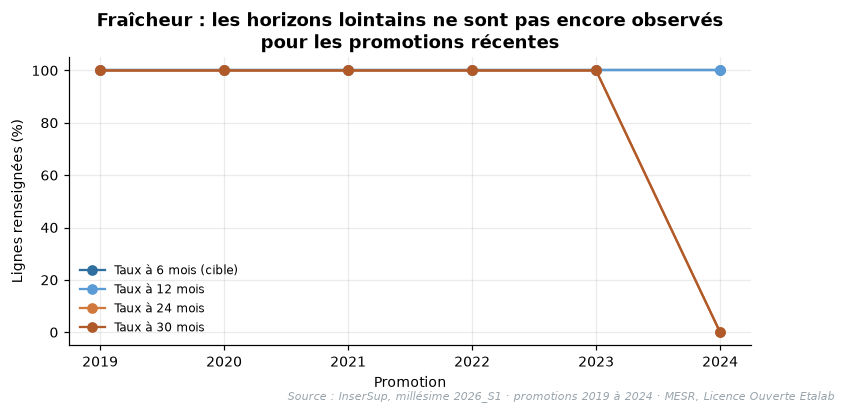

In [11]:
figure, axes = plt.subplots(figsize=(8, 3.4))
for horizon, couleur, etiquette in [
    ('cible_renseignee', COULEUR, 'Taux à 6 mois (cible)'),
    ('taux_12_mois', '#5b9bd5', 'Taux à 12 mois'),
    ('taux_24_mois', COULEUR_ALT, 'Taux à 24 mois'),
    ('taux_30_mois', '#b05a2a', 'Taux à 30 mois'),
]:
    axes.plot(fraicheur.index, fraicheur[horizon], marker='o', color=couleur, label=etiquette)
axes.set_xlabel('Promotion')
axes.set_ylabel('Lignes renseignées (%)')
axes.set_ylim(-5, 105)
axes.set_title("Fraîcheur : les horizons lointains ne sont pas encore observés\n"
               "pour les promotions récentes")
axes.legend(frameon=False, fontsize=8)
annoter_source()
plt.savefig(FIGURE_PATH / 'fig03_fraicheur.png')
plt.show()

La lecture est nette : la promotion 2024 est la **seule** à n'avoir aucun taux à 24 et
30 mois, parce qu'elle n'a pas encore atteint cet horizon au moment de la diffusion
`2026_S1`. Ses 2 942 lignes correspondent exactement aux 2 942 valeurs manquantes
détectées en A1 : le trou de complétude est donc entièrement expliqué par la mécanique de
publication, et par rien d'autre.

Cela dit deux choses. D'abord, **imputer ces valeurs n'aurait aucun sens** : ce serait
inventer un futur non observé. Ensuite, ces colonnes sont de toute façon inutilisables
comme prédicteurs de la cible à 6 mois, puisqu'elles sont mesurées après elle.

## A6. Rapport de qualité priorisé

Les problèmes sont classés par gravité pour la modélisation. La colonne « décision » est
ce que l'étape 3 devra exécuter.

In [12]:
rapport = pd.DataFrame([
    {'dimension': 'Fraîcheur', 'problème': 'Taux à 24 et 30 mois absents pour la promotion 2024',
     'ampleur': '2 942 lignes (17,2 %)', 'gravité': 'Bloquante',
     'décision': 'Exclure du modèle : mesure postérieure à la cible, non observable'},
    {'dimension': 'Cohérence', 'problème': "Horizons 12 et 18 mois corrélés à la cible",
     'ampleur': 'r = 0,85 et 0,79', 'gravité': 'Bloquante',
     'décision': 'Exclure : fuite de cible (information connue après la prédiction)'},
    {'dimension': 'Cohérence', 'problème': "Taux d'emploi stable et non salarié mesurés à 6 mois",
     'ampleur': '2 colonnes', 'gravité': 'Bloquante',
     'décision': "Exclure : résultats d'insertion mesurés au même horizon que la cible"},
    {'dimension': 'Unicité', 'problème': 'Libellés ambigus, aucune clé unique sans les codes',
     'ampleur': '107 lignes en trop', 'gravité': 'Majeure',
     'décision': 'Résolue : clé Code UAI × Code SISE × Promotion, aucun conflit restant'},
    {'dimension': 'Complétude', 'problème': 'Cardinalité forte (1 290 libellés, 329 établissements)',
     'ampleur': '3 colonnes', 'gravité': 'Majeure',
     'décision': 'Écarter du modèle de base ; conserver pour le feature engineering agrégé'},
    {'dimension': 'Cohérence', 'problème': "Taux d'emploi stable non reconstituable depuis les effectifs",
     'ampleur': '11 lignes (0,06 %)', 'gravité': 'Mineure',
     'décision': 'Signaler au nettoyage ; colonne exclue du modèle, aucun impact sur la cible'},
    {'dimension': 'Exactitude', 'problème': 'Cible à 0 ou 100 sur de petits effectifs',
     'ampleur': '44 lignes', 'gravité': 'Mineure',
     'décision': 'Conserver : valeurs réelles, pas des erreurs de saisie'},
    {'dimension': 'Exactitude', 'problème': 'Redondance Promotion / promotion_debut',
     'ampleur': '2 colonnes identiques', 'gravité': 'Mineure',
     'décision': 'Supprimer promotion_debut au nettoyage'},
    {'dimension': 'Complétude', 'problème': 'Seuil de publication à 20 sortants',
     'ampleur': 'structurel', 'gravité': 'Non corrigeable',
     'décision': 'Documenter comme biais de sélection, à annoncer en soutenance'},
])
rapport

,dimension,problème,ampleur,gravité,décision
0,Fraîcheur,Taux à 24 et 30 mois absents pour la promotion...,"2 942 lignes (17,2 %)",Bloquante,Exclure du modèle : mesure postérieure à la ci...
1,Cohérence,Horizons 12 et 18 mois corrélés à la cible,"r = 0,85 et 0,79",Bloquante,Exclure : fuite de cible (information connue a...
2,Cohérence,Taux d'emploi stable et non salarié mesurés à ...,2 colonnes,Bloquante,Exclure : résultats d'insertion mesurés au mêm...
3,Unicité,"Libellés ambigus, aucune clé unique sans les c...",107 lignes en trop,Majeure,Résolue : clé Code UAI × Code SISE × Promotion...
4,Complétude,"Cardinalité forte (1 290 libellés, 329 établis...",3 colonnes,Majeure,Écarter du modèle de base ; conserver pour le ...
5,Cohérence,Taux d'emploi stable non reconstituable depuis...,"11 lignes (0,06 %)",Mineure,Signaler au nettoyage ; colonne exclue du modè...
6,Exactitude,Cible à 0 ou 100 sur de petits effectifs,44 lignes,Mineure,"Conserver : valeurs réelles, pas des erreurs d..."
7,Exactitude,Redondance Promotion / promotion_debut,2 colonnes identiques,Mineure,Supprimer promotion_debut au nettoyage
8,Complétude,Seuil de publication à 20 sortants,structurel,Non corrigeable,"Documenter comme biais de sélection, à annonce..."


# Partie B - EDA analytique

Les cinq questions business formulées à l'étape 0 sont reprises ici une par une. Chaque
réponse est chiffrée, illustrée, et assortie de ce qu'elle ne permet **pas** de conclure.

## Q1. Quels types de formations ont les meilleurs taux d'insertion à 6 mois ?

Le type de diplôme est la variable de niveau le plus lisible pour un responsable
pédagogique. On ne retient que les types comptant au moins 100 formations, pour éviter de
comparer une moyenne solide à une moyenne calculée sur quelques lignes.

In [13]:
SEUIL_GROUPE = 100

q1 = (df.groupby('Type de diplôme')
        .agg(formations=(TARGET, 'size'), moyenne=(TARGET, 'mean'),
             mediane=(TARGET, 'median'), ecart_type=(TARGET, 'std'),
             sortants_medians=(SORTANTS, 'median'))
        .round(2))
q1_filtre = q1[q1['formations'] >= SEUIL_GROUPE].sort_values('moyenne', ascending=False)

meilleur, pire = q1_filtre.index[0], q1_filtre.index[-1]
ecart = q1_filtre['moyenne'].iloc[0] - q1_filtre['moyenne'].iloc[-1]
print(f'Réponse Q1 : sur les {len(q1_filtre)} types de diplôme comptant au moins '
      f'{SEUIL_GROUPE} formations,')
print(f'  · le mieux inséré est « {meilleur} » à {q1_filtre["moyenne"].iloc[0]:.1f} %')
print(f'  · le moins bien inséré est « {pire} » à {q1_filtre["moyenne"].iloc[-1]:.1f} %')
print(f'  · soit un écart de {ecart:.1f} points, '
      f'{ecart / df[TARGET].std():.1f} fois l\'écart-type de la cible '
      f'({df[TARGET].std():.1f} points)')
print(f'  · {len(q1) - len(q1_filtre)} types sont écartés faute d\'effectif suffisant')
q1_filtre

Réponse Q1 : sur les 9 types de diplôme comptant au moins 100 formations,
  · le mieux inséré est « Master MEEF » à 80.7 %
  · le moins bien inséré est « Diplôme visé niveau bac + 3 » à 34.6 %
  · soit un écart de 46.1 points, 2.5 fois l'écart-type de la cible (18.5 points)
  · 2 types sont écartés faute d'effectif suffisant


,formations,moyenne,mediane,ecart_type,sortants_medians
Type de diplôme,,,,,
Master MEEF,458,80.68,85.22,15.49,138.0
Licence professionnelle,1978,71.20,74.41,17.26,27.0
Diplôme d'ingénieurs,2633,62.12,63.27,13.65,51.0
Bachelor universitaire de technologie,217,61.85,62.50,14.34,30.0
Master LMD,8388,53.21,53.57,16.63,36.0
Diplôme visé niveau bac + 5 grade master,686,46.91,48.36,14.50,107.5
Licence générale,2332,45.88,45.11,15.97,36.0
Diplôme visé niveau bac + 3 ou bac + 4 grade licence,131,37.47,28.57,26.86,47.0
Diplôme visé niveau bac + 3,134,34.61,33.33,17.14,58.5


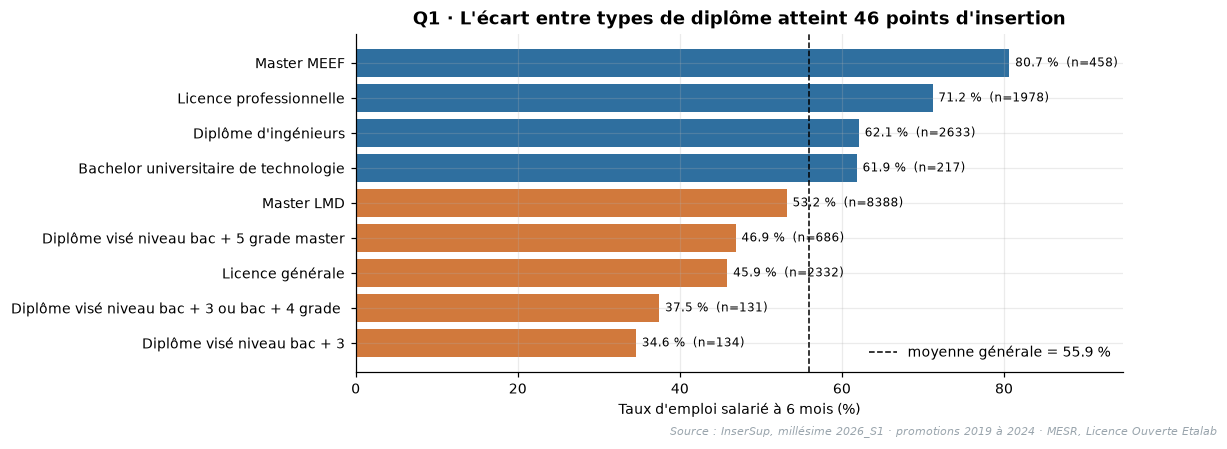

In [14]:
figure, axes = plt.subplots(figsize=(9, 4))
positions = range(len(q1_filtre))
couleurs = [COULEUR_ALT if valeur < df[TARGET].mean() else COULEUR
            for valeur in q1_filtre['moyenne']]
axes.barh(positions, q1_filtre['moyenne'], color=couleurs)
axes.set_yticks(positions)
axes.set_yticklabels([nom[:45] for nom in q1_filtre.index])
axes.invert_yaxis()
axes.axvline(df[TARGET].mean(), color='black', linestyle='--', linewidth=1,
             label=f"moyenne générale = {df[TARGET].mean():.1f} %")
axes.set_xlabel("Taux d'emploi salarié à 6 mois (%)")
axes.set_title("Q1 · L'écart entre types de diplôme atteint "
               f"{ecart:.0f} points d'insertion")
axes.legend(frameon=False, loc='lower right')
for position, (valeur, effectif) in enumerate(zip(q1_filtre['moyenne'], q1_filtre['formations'])):
    axes.text(valeur + 0.7, position, f'{valeur:.1f} %  (n={effectif})', va='center', fontsize=8)
axes.set_xlim(0, q1_filtre['moyenne'].max() + 14)
annoter_source()
plt.savefig(FIGURE_PATH / 'fig04_q1_type_diplome.png')
plt.show()

**Lecture.** Le classement oppose deux logiques. En tête, les diplômes qui mènent
directement à un métier : Master MEEF (80,7 %, l'enseignement recrute ses diplômés),
licence professionnelle (71,2 %), diplôme d'ingénieurs (62,1 %). En queue, les diplômes
de niveau bac + 3 non professionnalisants et la licence générale (45,9 %), qui mènent
majoritairement à une poursuite d'études : un étudiant qui poursuit n'est pas en emploi
salarié, et fait donc mécaniquement baisser le taux.

L'écart de 46 points entre le premier et le dernier vaut deux fois et demie l'écart-type
de la cible. La colonne « nombre de poursuivants » devrait donc porter un signal fort, ce
que la section sur les corrélations permettra de vérifier.

**Ce que cela ne dit pas.** Rien ici ne prouve qu'inscrire un étudiant en licence
professionnelle améliore son employabilité : les publics, les disciplines et les
territoires diffèrent d'un type de diplôme à l'autre.

## Q2. Existe-t-il des différences selon le domaine, la discipline ou l'établissement ?

In [15]:
q2_domaine = (df.groupby('Domaine disciplinaire')
                .agg(formations=(TARGET, 'size'), moyenne=(TARGET, 'mean'),
                     mediane=(TARGET, 'median'))
                .sort_values('moyenne', ascending=False).round(2))

q2_secteur = (df.groupby('Secteur disciplinaire')
                .agg(formations=(TARGET, 'size'), moyenne=(TARGET, 'mean'))
                .query(f'formations >= {SEUIL_GROUPE}')
                .sort_values('moyenne', ascending=False).round(2))

print('Par domaine disciplinaire :')
print(q2_domaine.to_string())
print()
print(f"Écart entre le premier et le dernier domaine : "
      f"{q2_domaine['moyenne'].iloc[0] - q2_domaine['moyenne'].iloc[-1]:.1f} points")
print()
print(f"Sur les {len(q2_secteur)} secteurs disciplinaires d'au moins {SEUIL_GROUPE} formations,")
print(f"  · trois meilleurs : {', '.join(q2_secteur.index[:3])}")
print(f"  · trois derniers  : {', '.join(q2_secteur.index[-3:])}")
print(f"  · amplitude : {q2_secteur['moyenne'].iloc[0] - q2_secteur['moyenne'].iloc[-1]:.1f} points, "
      f"soit plus du double de l'écart entre domaines")

Par domaine disciplinaire :
                               formations  moyenne  mediane
Domaine disciplinaire                                      
Sciences, technologies, santé        7091    59.75    60.71
Sciences humaines et sociales        2741    57.82    57.14
Droit, économie, gestion             5553    54.40    54.98
Lettres, langues et arts             1680    41.38    40.97

Écart entre le premier et le dernier domaine : 18.4 points

Sur les 31 secteurs disciplinaires d'au moins 100 formations,
  · trois meilleurs : Sciences de l'éducation, Génie civil, Génie des procédés, matériaux
  · trois derniers  : Pluridisciplinaire lettres, langues, sciences humaines, Sciences politiques, Langues et littératures étrangères
  · amplitude : 37.2 points, soit plus du double de l'écart entre domaines


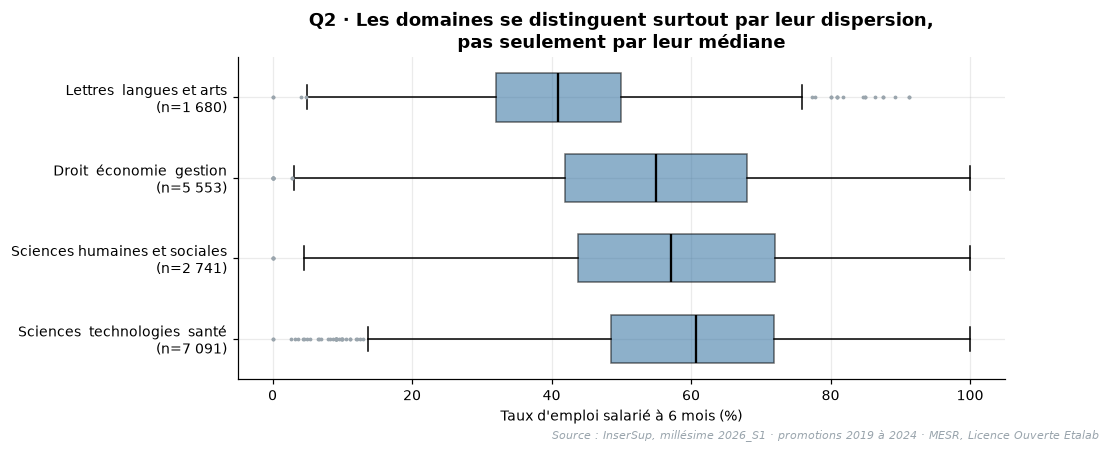

In [16]:
ordre = q2_domaine.index.tolist()
donnees = [df.loc[df['Domaine disciplinaire'] == domaine, TARGET].dropna() for domaine in ordre]

figure, axes = plt.subplots(figsize=(9, 3.8))
boites = axes.boxplot(donnees, orientation='horizontal', patch_artist=True, widths=0.6,
                      medianprops={'color': 'black', 'linewidth': 1.5},
                      flierprops={'marker': '.', 'markersize': 3,
                                  'markerfacecolor': COULEUR_NEUTRE,
                                  'markeredgecolor': COULEUR_NEUTRE})
for boite in boites['boxes']:
    boite.set(facecolor=COULEUR, alpha=0.55)
axes.set_yticklabels([f'{nom}\n(n={q2_domaine.loc[nom, "formations"]:,.0f})'.replace(',', ' ')
                      for nom in ordre])
axes.set_xlabel("Taux d'emploi salarié à 6 mois (%)")
axes.set_title("Q2 · Les domaines se distinguent surtout par leur dispersion,\n"
               "pas seulement par leur médiane")
annoter_source()
plt.savefig(FIGURE_PATH / 'fig05_q2_domaine.png')
plt.show()

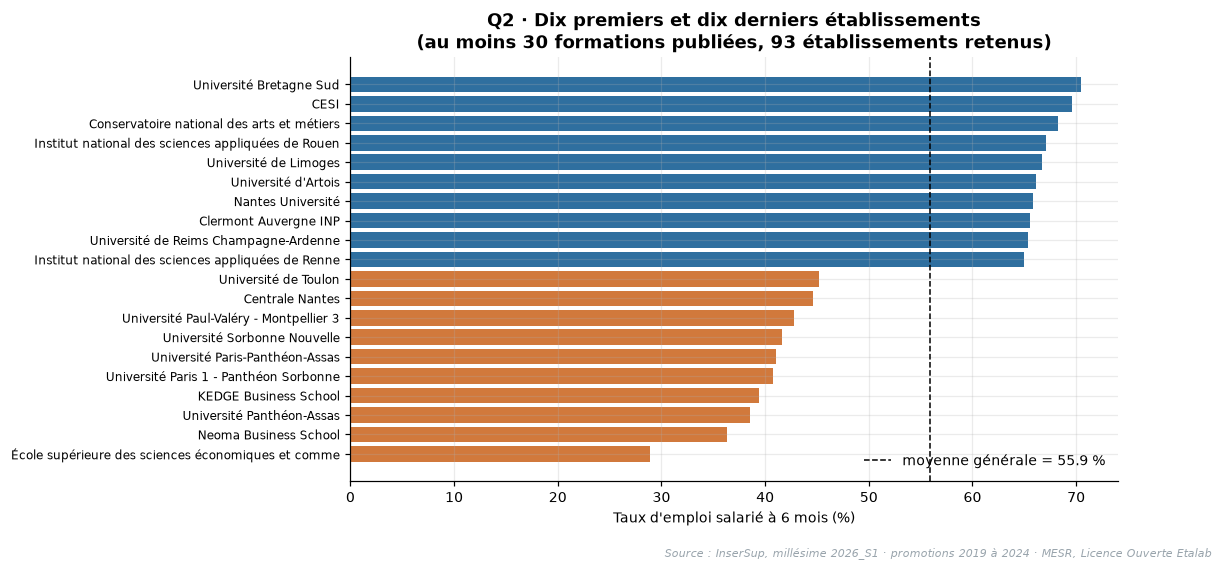

Amplitude entre établissements : 41.6 points
Écart-type des moyennes d'établissement : 8.0 points


In [17]:
SEUIL_ETABLISSEMENT = 30
q2_etablissement = (df.groupby('Établissement')
                      .agg(formations=(TARGET, 'size'), moyenne=(TARGET, 'mean'))
                      .query(f'formations >= {SEUIL_ETABLISSEMENT}')
                      .sort_values('moyenne', ascending=False).round(2))

tete = q2_etablissement.head(10)
queue = q2_etablissement.tail(10)
extremes = pd.concat([tete, queue])

figure, axes = plt.subplots(figsize=(9, 5))
couleurs = [COULEUR] * len(tete) + [COULEUR_ALT] * len(queue)
positions = range(len(extremes))
axes.barh(positions, extremes['moyenne'], color=couleurs)
axes.set_yticks(positions)
axes.set_yticklabels([nom[:50] for nom in extremes.index], fontsize=8)
axes.invert_yaxis()
axes.axvline(df[TARGET].mean(), color='black', linestyle='--', linewidth=1,
             label=f"moyenne générale = {df[TARGET].mean():.1f} %")
axes.set_xlabel("Taux d'emploi salarié à 6 mois (%)")
axes.set_title(f"Q2 · Dix premiers et dix derniers établissements\n"
               f"(au moins {SEUIL_ETABLISSEMENT} formations publiées, "
               f"{len(q2_etablissement)} établissements retenus)")
axes.legend(frameon=False, loc='lower right')
annoter_source()
plt.savefig(FIGURE_PATH / 'fig06_q2_etablissements.png')
plt.show()

print(f"Amplitude entre établissements : "
      f"{q2_etablissement['moyenne'].iloc[0] - q2_etablissement['moyenne'].iloc[-1]:.1f} points")
print(f"Écart-type des moyennes d'établissement : {q2_etablissement['moyenne'].std():.1f} points")

**Lecture.** L'amplitude entre secteurs disciplinaires dépasse largement l'amplitude entre
domaines : agréger au niveau du domaine écrase l'essentiel du signal. C'est un argument
direct pour donner au modèle le **secteur disciplinaire** plutôt que le seul domaine.

L'écart entre établissements est réel, mais il faut se méfier : un établissement
spécialisé dans un seul secteur hérite de la performance de ce secteur. La question
« l'établissement ajoute-t-il quelque chose une fois la discipline connue ? » est une
question de modélisation, pas d'EDA, et elle sera tranchée par l'importance des variables
à l'étape 5.

## Q3. Genre, nationalité, régime d'inscription : quels facteurs sont associés à l'emploi ?

Cette question ne peut pas être traitée sur le jeu de modélisation, où la démographie est
agrégée à `ensemble`. Elle utilise le **jeu analytique**, en ne faisant varier qu'une
dimension démographique à la fois et en gardant les autres à `ensemble`.

In [18]:
COLONNES_Q3 = ['Établissement', 'Type de diplôme', 'Libellé du diplôme', 'Promotion',
               'Genre', 'Nationalité', "Régime d'inscription", 'Obtention du diplôme',
               'promotion_cumulee', 'marge_geo_disc', TARGET]
types_q3 = {colonne: str for colonne in COLONNES_Q3 if colonne != TARGET}

analytique = pd.read_csv(ANALYTIC_PATH, usecols=COLONNES_Q3, dtype=types_q3)
comparable = analytique[
    analytique['promotion_cumulee'].eq('False')
    & analytique['marge_geo_disc'].eq('False')
    & analytique['Obtention du diplôme'].eq('diplômé')
]
print('Jeu analytique :', len(analytique), 'lignes')
print('Périmètre comparable (promotion simple, hors marges, diplômés) :',
      len(comparable), 'lignes')

resultats_q3 = []
for dimension, autres in [
    ('Genre', ['Nationalité', "Régime d'inscription"]),
    ('Nationalité', ['Genre', "Régime d'inscription"]),
    ("Régime d'inscription", ['Genre', 'Nationalité']),
]:
    sous_ensemble = comparable
    for autre in autres:
        sous_ensemble = sous_ensemble[sous_ensemble[autre].eq('ensemble')]
    agrege = sous_ensemble.groupby(dimension)[TARGET].agg(['count', 'mean', 'median']).round(2)
    for modalite, ligne in agrege.iterrows():
        resultats_q3.append({'dimension': dimension, 'modalité': modalite,
                             'lignes': int(ligne['count']), 'moyenne': ligne['mean'],
                             'médiane': ligne['median']})

pd.DataFrame(resultats_q3)

Jeu analytique : 438696 lignes
Périmètre comparable (promotion simple, hors marges, diplômés) : 72970 lignes


,dimension,modalité,lignes,moyenne,médiane
0,Genre,ensemble,17065,55.89,56.10
1,Genre,femme,8919,54.57,54.55
2,Genre,homme,7393,57.40,57.73
3,Nationalité,ensemble,17065,55.89,56.10
4,Nationalité,français,14340,59.74,60.00
5,Régime d'inscription,apprentissage,3793,66.57,66.67
6,Régime d'inscription,ensemble,17065,55.89,56.10


In [19]:
# Comparaison appariée : on ne compare hommes et femmes que dans les formations
# où les deux sont publiés, pour neutraliser l'effet de composition.
CLE_APPARIEMENT = ['Établissement', 'Type de diplôme', 'Libellé du diplôme', 'Promotion']
base_genre = comparable[comparable['Nationalité'].eq('ensemble')
                        & comparable["Régime d'inscription"].eq('ensemble')
                        & comparable['Genre'].isin(['homme', 'femme'])]
apparie = (base_genre.pivot_table(index=CLE_APPARIEMENT, columns='Genre', values=TARGET)
                     .dropna())
ecart_apparie = apparie['femme'] - apparie['homme']

brut_femme = base_genre.loc[base_genre['Genre'].eq('femme'), TARGET].mean()
brut_homme = base_genre.loc[base_genre['Genre'].eq('homme'), TARGET].mean()

print(f'Comparaison brute (toutes formations publiées, effectifs différents) :')
print(f'  femmes {brut_femme:.2f} %  ·  hommes {brut_homme:.2f} %  '
      f'→ écart {brut_femme - brut_homme:+.2f} point en faveur des hommes')
print()
print(f'Comparaison appariée sur {len(apparie)} formations où les deux sont publiés :')
print(f'  femmes {apparie["femme"].mean():.2f} %  ·  hommes {apparie["homme"].mean():.2f} %  '
      f'→ écart {ecart_apparie.mean():+.2f} point en faveur des femmes')
print(f'  les femmes sont mieux insérées dans {100 * (ecart_apparie > 0).mean():.1f} % '
      f'des formations comparées')

Comparaison brute (toutes formations publiées, effectifs différents) :
  femmes 54.57 %  ·  hommes 57.40 %  → écart -2.84 point en faveur des hommes

Comparaison appariée sur 4026 formations où les deux sont publiés :
  femmes 55.37 %  ·  hommes 52.99 %  → écart +2.38 point en faveur des femmes
  les femmes sont mieux insérées dans 58.8 % des formations comparées


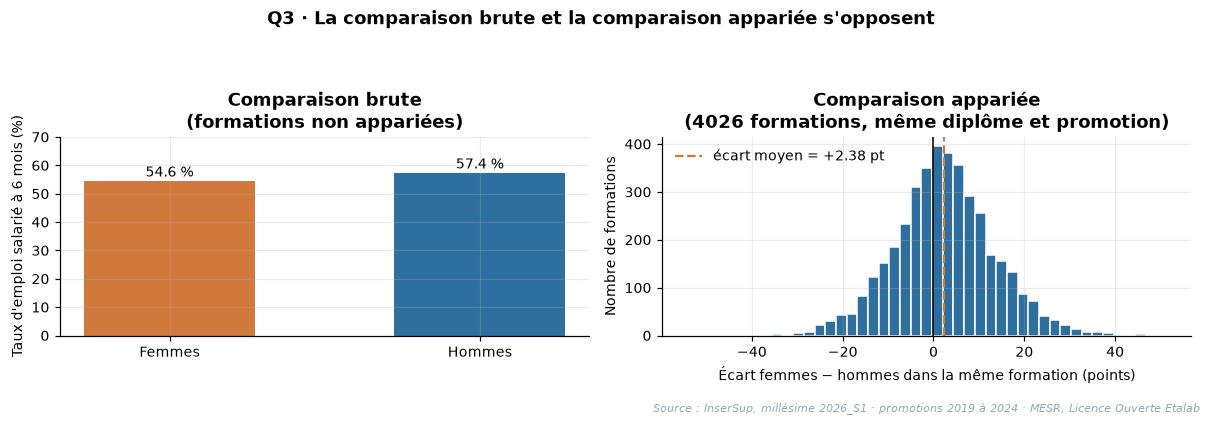

In [20]:
figure, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar(['Femmes', 'Hommes'], [brut_femme, brut_homme],
            color=[COULEUR_ALT, COULEUR], width=0.55)
axes[0].set_ylabel("Taux d'emploi salarié à 6 mois (%)")
axes[0].set_ylim(0, 70)
axes[0].set_title('Comparaison brute\n(formations non appariées)')
for position, valeur in enumerate([brut_femme, brut_homme]):
    axes[0].text(position, valeur + 1.5, f'{valeur:.1f} %', ha='center', fontsize=9)

axes[1].hist(ecart_apparie, bins=45, color=COULEUR, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].axvline(ecart_apparie.mean(), color=COULEUR_ALT, linestyle='--',
                label=f'écart moyen = {ecart_apparie.mean():+.2f} pt')
axes[1].set_xlabel('Écart femmes − hommes dans la même formation (points)')
axes[1].set_ylabel('Nombre de formations')
axes[1].set_title(f'Comparaison appariée\n({len(apparie)} formations, même diplôme et promotion)')
axes[1].legend(frameon=False)

figure.suptitle("Q3 · La comparaison brute et la comparaison appariée s'opposent",
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.90))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig07_q3_genre.png')
plt.show()

**Découverte inattendue.** Les deux lectures se contredisent. Comparées globalement, les
femmes affichent un taux d'emploi salarié inférieur à celui des hommes. Comparées **à
formation, diplôme et promotion identiques**, elles sont mieux insérées en moyenne, et
majoritairement mieux insérées formation par formation.

L'explication est un effet de composition : hommes et femmes ne sont pas répartis de la
même façon entre les disciplines, et les disciplines n'ont pas le même débouché. L'écart
brut mesure donc surtout l'orientation, pas l'insertion à formation égale. C'est
exactement le type de raisonnement qu'un modèle entraîné sans variable de discipline
reproduirait à tort.

Le régime d'apprentissage ressort par ailleurs très nettement au-dessus de l'ensemble, ce
qui est cohérent avec l'idée qu'un contrat d'apprentissage débouche souvent sur une
embauche dans la même entreprise.

**Limite forte.** Ces trois variables ne sont pas dans le jeu de modélisation : le modèle
construit aux étapes 4 et 5 **ne peut donc rien dire** sur d'éventuelles disparités de
genre ou de nationalité. Une analyse d'équité demanderait de reconstruire le jeu à ce
niveau de détail.

## Q4. Quelles formations sont les plus fragiles en insertion ?

Deux mesures se complètent : le taux d'emploi salarié (est-on en emploi ?) et le taux
d'emploi stable (l'emploi est-il durable ?). Une formation peut réussir sur la première et
échouer sur la seconde.

In [21]:
q4 = (df.groupby(['Type de diplôme', 'Secteur disciplinaire'])
        .agg(formations=(TARGET, 'size'), taux_emploi=(TARGET, 'mean'),
             taux_stable=(TX_STABLE, 'mean'))
        .query(f'formations >= {SEUIL_GROUPE}')
        .round(2))

print(f"Sur {len(q4)} couples (type de diplôme × secteur) d'au moins {SEUIL_GROUPE} formations :")
print()
print('Cinq combinaisons les plus fragiles sur le taux d\'emploi :')
print(q4.sort_values('taux_emploi').head(5).to_string())
print()
print('Cinq combinaisons les plus fragiles sur la stabilité de l\'emploi :')
print(q4.sort_values('taux_stable').head(5).to_string())

Sur 44 couples (type de diplôme × secteur) d'au moins 100 formations :

Cinq combinaisons les plus fragiles sur le taux d'emploi :
                                                                                    formations  taux_emploi  taux_stable
Type de diplôme             Secteur disciplinaire                                                                       
Licence générale            Pluridisciplinaire sciences économiques et gestion             153        35.76        50.54
Diplôme visé niveau bac + 3 Sciences de gestion                                            103        36.94        56.85
Licence générale            Langues et littératures étrangères                             191        39.91        45.54
                            Langues étrangères appliquées                                  224        41.94        45.41
Master LMD                  Pluridisciplinaire lettres, langues, sciences humaines         109        42.11        36.49

Cinq combinaisons les

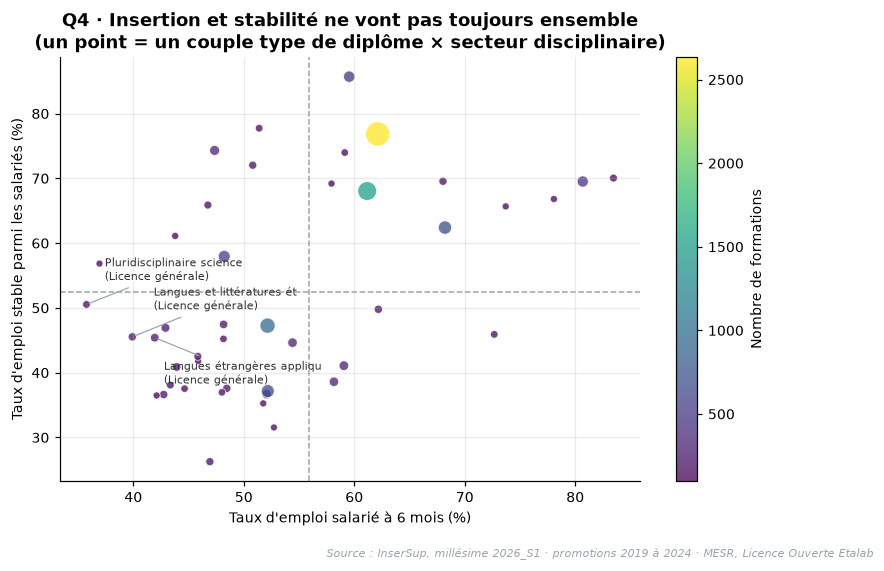

Corrélation entre taux d'emploi et taux d'emploi stable : 0.466
Combinaisons sous les deux moyennes (zone à risque) : 22 sur 44


In [22]:
figure, axes = plt.subplots(figsize=(8.5, 5))
tailles = 12 + q4['formations'] / q4['formations'].max() * 240
nuage = axes.scatter(q4['taux_emploi'], q4['taux_stable'], s=tailles,
                     c=q4['formations'], cmap='viridis', alpha=0.75,
                     edgecolor='white', linewidth=0.6)
axes.axvline(df[TARGET].mean(), color=COULEUR_NEUTRE, linestyle='--', linewidth=1)
axes.axhline(q4['taux_stable'].mean(), color=COULEUR_NEUTRE, linestyle='--', linewidth=1)
axes.set_xlabel("Taux d'emploi salarié à 6 mois (%)")
axes.set_ylabel("Taux d'emploi stable parmi les salariés (%)")
axes.set_title("Q4 · Insertion et stabilité ne vont pas toujours ensemble\n"
               "(un point = un couple type de diplôme × secteur disciplinaire)")
figure.colorbar(nuage, ax=axes, label='Nombre de formations')

# On annote les trois points les plus à risque : sous les deux moyennes.
fragiles = q4[(q4['taux_emploi'] < df[TARGET].mean())
              & (q4['taux_stable'] < q4['taux_stable'].mean())]
decalages = [(12, 16), (14, 18), (6, -30)]
for decalage, ((diplome, secteur), ligne) in zip(
        decalages, fragiles.nsmallest(3, 'taux_emploi').iterrows()):
    axes.annotate(f'{secteur[:26]}\n({diplome[:22]})',
                  (ligne['taux_emploi'], ligne['taux_stable']),
                  textcoords='offset points', xytext=decalage, fontsize=7,
                  color='#333333',
                  arrowprops={'arrowstyle': '-', 'color': COULEUR_NEUTRE, 'linewidth': 0.8})
annoter_source()
plt.savefig(FIGURE_PATH / 'fig08_q4_fragilite.png')
plt.show()

print(f"Corrélation entre taux d'emploi et taux d'emploi stable : "
      f"{q4['taux_emploi'].corr(q4['taux_stable']):.3f}")
print(f"Combinaisons sous les deux moyennes (zone à risque) : {len(fragiles)} sur {len(q4)}")

## Q5. Les performances d'insertion ont-elles évolué au fil des promotions ?

In [23]:
q5_global = df.groupby('Promotion')[TARGET].agg(['size', 'mean', 'median', 'std']).round(2)
q5_domaine = (df.pivot_table(index='Promotion', columns='Domaine disciplinaire',
                             values=TARGET, aggfunc='mean').round(2))

creux = q5_global['mean'].idxmin()
sommet = q5_global['mean'].idxmax()
print(f"Point bas : promotion {creux} à {q5_global.loc[creux, 'mean']:.1f} %")
print(f"Point haut : promotion {sommet} à {q5_global.loc[sommet, 'mean']:.1f} %")
print(f"Amplitude sur six promotions : "
      f"{q5_global['mean'].max() - q5_global['mean'].min():.1f} points")
print(f"Repli entre {sommet} et {df['Promotion'].max()} : "
      f"{q5_global.loc[df['Promotion'].max(), 'mean'] - q5_global.loc[sommet, 'mean']:+.1f} points")
q5_global

Point bas : promotion 2020 à 48.2 %
Point haut : promotion 2022 à 61.6 %
Amplitude sur six promotions : 13.4 points
Repli entre 2022 et 2024 : -7.2 points


,size,mean,median,std
Promotion,,,,
2019,2657,52.70,52.63,18.54
2020,2710,48.20,46.43,18.87
2021,2933,59.17,60.00,17.77
2022,2958,61.60,62.16,17.56
2023,2865,58.40,58.82,17.80
2024,2942,54.39,54.38,17.09


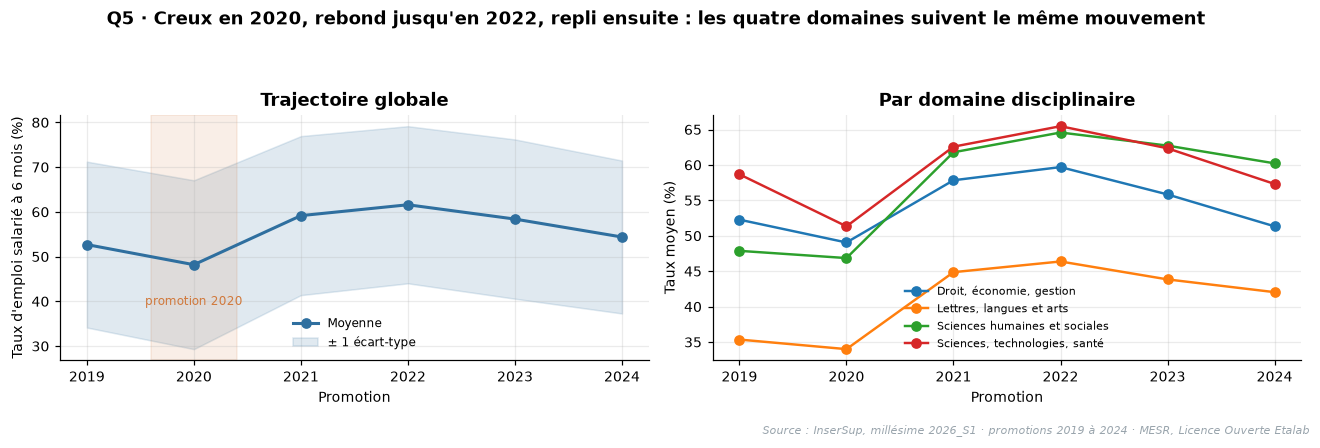

In [24]:
figure, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].plot(q5_global.index, q5_global['mean'], marker='o', color=COULEUR, linewidth=2,
             label='Moyenne')
axes[0].fill_between(q5_global.index,
                     q5_global['mean'] - q5_global['std'],
                     q5_global['mean'] + q5_global['std'],
                     color=COULEUR, alpha=0.15, label='± 1 écart-type')
axes[0].axvspan(2019.6, 2020.4, color=COULEUR_ALT, alpha=0.12)
axes[0].annotate('promotion 2020', (2020, q5_global.loc[2020, 'mean'] - 9),
                 ha='center', fontsize=8, color=COULEUR_ALT)
axes[0].set_xlabel('Promotion')
axes[0].set_ylabel("Taux d'emploi salarié à 6 mois (%)")
axes[0].set_title('Trajectoire globale')
axes[0].legend(frameon=False, fontsize=8)

for domaine in q5_domaine.columns:
    axes[1].plot(q5_domaine.index, q5_domaine[domaine], marker='o', linewidth=1.6,
                 label=domaine[:34])
axes[1].set_xlabel('Promotion')
axes[1].set_ylabel("Taux moyen (%)")
axes[1].set_title('Par domaine disciplinaire')
axes[1].legend(frameon=False, fontsize=7.5)

figure.suptitle("Q5 · Creux en 2020, rebond jusqu'en 2022, repli ensuite : "
                'les quatre domaines suivent le même mouvement',
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.90))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig09_q5_promotions.png')
plt.show()

**Lecture.** Le creux de la promotion 2020 et le rebond de 2021-2022 se retrouvent dans les
quatre domaines simultanément. Un mouvement commun à des disciplines aussi différentes
pointe vers une cause extérieure aux formations elles-mêmes : le marché du travail au
moment de la sortie, la promotion 2020 étant celle qui est arrivée sur le marché en pleine
crise sanitaire.

**Conséquence pour la modélisation.** La promotion n'est pas une simple étiquette : elle
porte un effet de conjoncture. Elle doit donc être fournie au modèle. Mais cela signifie
aussi qu'un modèle entraîné sur 2019-2024 ne saura pas anticiper un choc conjoncturel
inédit sur une promotion future : c'est ce que la validation temporelle de l'étape 5 va
chiffrer.

## B6. Lien entre les variables et la cible

Cette section prépare directement la modélisation : quelles variables portent du signal,
et lesquelles en portent trop pour être honnêtes.

In [25]:
colonnes_numeriques = df.select_dtypes(include='number').columns.tolist()
correlations = df[colonnes_numeriques].corr()[TARGET].drop(TARGET).sort_values(key=abs,
                                                                              ascending=False)

# Force du lien des variables catégorielles : part de variance de la cible expliquée
# par la seule appartenance au groupe (rapport de corrélation eta²).
variance_totale = df[TARGET].var(ddof=0)
eta_carre = {}
COLONNES_CATEGORIELLES = ['Région', 'Académie', 'Établissement', 'Type de diplôme',
                          'Domaine disciplinaire', 'Discipline', 'Secteur disciplinaire',
                          'Libellé du diplôme', CODE_UAI, CODE_SISE]
for colonne in COLONNES_CATEGORIELLES:
    moyennes = df.groupby(colonne)[TARGET].transform('mean')
    eta_carre[colonne] = round(moyennes.var(ddof=0) / variance_totale, 3)
eta_carre = pd.Series(eta_carre).sort_values(ascending=False)

print('Corrélation de Pearson avec la cible (variables numériques) :')
print(correlations.round(3).to_string())
print()
print("Part de la variance de la cible expliquée par chaque variable catégorielle (eta²) :")
print(eta_carre.to_string())

Corrélation de Pearson avec la cible (variables numériques) :
12-Taux d'emploi salarié en France - 12 mois après le diplôme           0.849
18-Taux d'emploi salarié en France - 18 mois après le diplôme           0.794
24-Taux d'emploi salarié en France - 24 mois après le diplôme           0.760
30-Taux d'emploi salarié en France - 30 mois après le diplôme           0.743
6-Taux de sortants en emploi stable - 6 mois après le diplôme           0.324
6-Nombre de poursuivants - 6 mois après le diplôme                     -0.236
6-Nombre de sortants en emploi stable - 6 mois après le diplôme         0.220
promotion_debut                                                         0.105
Promotion                                                               0.105
6-Taux de sortants en emploi non salarié - 6 mois après le diplôme     -0.098
6-Nombre de sortants en emploi non salarié - 6 mois après le diplôme   -0.066
6-Nombre de sortants - 6 mois après le diplôme                          0.017

P

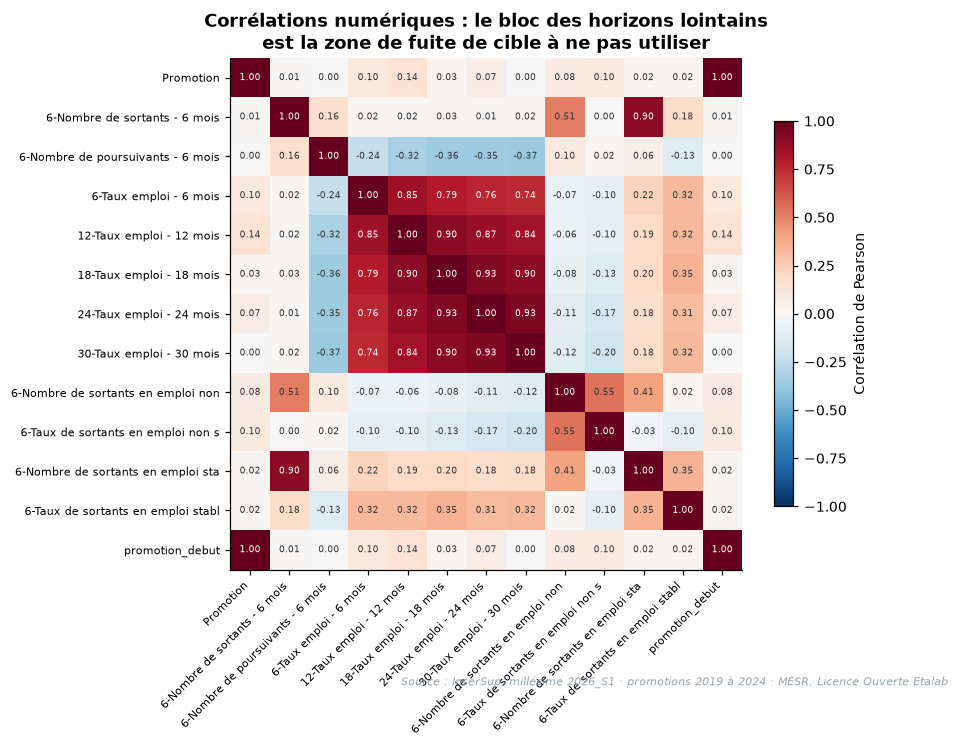

In [26]:
matrice = df[colonnes_numeriques].corr()
etiquettes = [nom.replace(' après le diplôme', '').replace("Taux d'emploi salarié en France", "Taux emploi")[:34]
              for nom in matrice.columns]

figure, axes = plt.subplots(figsize=(7.5, 6.5))
image = axes.imshow(matrice, cmap='RdBu_r', vmin=-1, vmax=1)
axes.set_xticks(range(len(etiquettes)))
axes.set_xticklabels(etiquettes, rotation=45, ha='right', fontsize=7)
axes.set_yticks(range(len(etiquettes)))
axes.set_yticklabels(etiquettes, fontsize=7)
axes.grid(False)
for i in range(len(matrice)):
    for j in range(len(matrice)):
        valeur = matrice.iloc[i, j]
        axes.text(j, i, f'{valeur:.2f}', ha='center', va='center', fontsize=6,
                  color='white' if abs(valeur) > 0.55 else '#333333')
axes.set_title("Corrélations numériques : le bloc des horizons lointains\n"
               "est la zone de fuite de cible à ne pas utiliser")
figure.colorbar(image, ax=axes, shrink=0.7, label='Corrélation de Pearson')
annoter_source()
plt.savefig(FIGURE_PATH / 'fig10_correlations.png')
plt.show()

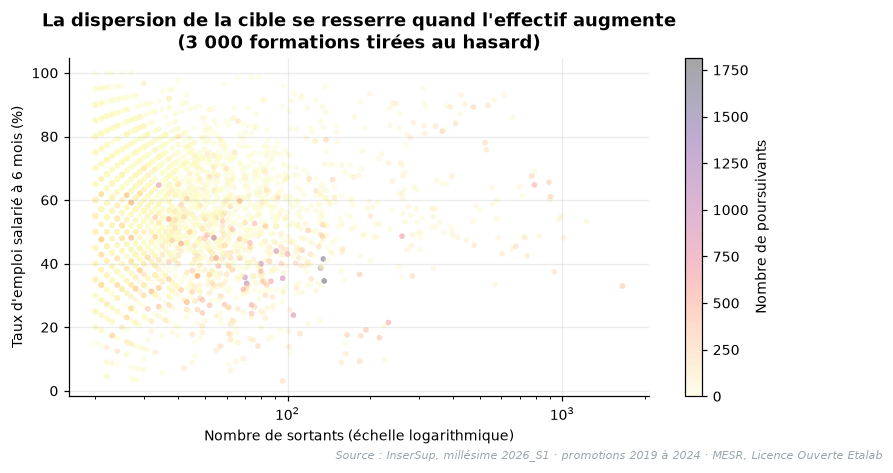

Dispersion de la cible par quintile d'effectif :


,size,mean,std
tranche,,,
"(19.999, 24.0]",3558,57.12,20.33
"(24.0, 32.0]",3529,56.30,18.78
"(32.0, 44.0]",3199,55.58,17.98
"(44.0, 71.0]",3388,54.61,17.13
"(71.0, 1882.0]",3391,55.75,17.74


In [27]:
figure, axes = plt.subplots(figsize=(8.5, 4))
echantillon = df.sample(3000, random_state=42)
nuage = axes.scatter(echantillon[SORTANTS], echantillon[TARGET],
                     s=14, alpha=0.35, c=echantillon[POURSUIVANTS],
                     cmap='magma_r', edgecolor='none')
axes.set_xscale('log')
axes.set_xlabel("Nombre de sortants (échelle logarithmique)")
axes.set_ylabel("Taux d'emploi salarié à 6 mois (%)")
axes.set_title("La dispersion de la cible se resserre quand l'effectif augmente\n"
               "(3 000 formations tirées au hasard)")
figure.colorbar(nuage, ax=axes, label='Nombre de poursuivants')

dispersion = (df.assign(tranche=pd.qcut(df[SORTANTS], 5))
                .groupby('tranche', observed=True)[TARGET]
                .agg(['size', 'mean', 'std']).round(2))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig11_effectif_dispersion.png')
plt.show()

print("Dispersion de la cible par quintile d'effectif :")
dispersion

### Hypothèses sur ce que le modèle devrait apprendre

1. **Le nombre de poursuivants est le prédicteur numérique le plus prometteur.** Une
   formation dont beaucoup de diplômés poursuivent leurs études a mécaniquement moins de
   sortants en emploi. Le rapport poursuivants / sortants devrait porter plus de signal
   que chacun des deux effectifs pris isolément : c'est une feature à construire à
   l'étape 3.
2. **Le type de diplôme et le secteur disciplinaire devraient dominer les variables
   catégorielles** (eta² de 0,23 et 0,19), très loin devant la région (0,06). Le domaine
   disciplinaire n'explique que 0,08 de la variance contre 0,19 pour le secteur : donner
   au modèle l'agrégat plutôt que le détail perdrait plus de la moitié du signal
   disciplinaire.
   Le code SISE affiche le eta² le plus élevé (0,54), mais avec 1 408 modalités il
   mémoriserait les formations au lieu d'apprendre : il sera exploité sous forme de
   variables dérivées, pas encodé directement.
3. **La promotion apportera un effet de niveau** (conjoncture), pas une tendance.
4. **L'erreur du modèle devrait être plus forte sur les petits effectifs**, où la cible
   est intrinsèquement plus bruitée. Cette hypothèse sera vérifiée dans l'analyse des
   erreurs de l'étape 5.
5. **Le plafond de performance sera modeste.** Aucune variable disponible ne dépasse une
   corrélation modérée avec la cible une fois les horizons futurs exclus : un $R^2$ autour
   de 0,5 est un objectif réaliste, pas un échec.

## B7. Synthèse : le récit en cinq phrases

1. L'insertion à six mois se joue d'abord sur **ce qu'on étudie** : le secteur
   disciplinaire ouvre un écart plus large que le domaine, la région ou l'établissement.
2. Elle se joue ensuite sur **la vocation du diplôme** : les formations
   professionnalisantes insèrent nettement mieux que les formations qui mènent à une
   poursuite d'études, et l'apprentissage amplifie encore cet écart.
3. Elle se joue enfin sur **le moment de la sortie** : la promotion 2020 paie la crise
   sanitaire dans les quatre domaines à la fois.
4. L'écart d'insertion entre femmes et hommes **change de signe** selon qu'on compare
   globalement ou à formation identique : l'écart brut mesure l'orientation, pas
   l'insertion.
5. Les indicateurs mesurés après six mois sont fortement corrélés à la cible et
   **doivent être écartés** : ils décriraient le futur qu'on prétend prédire.

## B8. Décisions transmises à l'étape 3

1. Conserver la cible `6-Taux d'emploi salarié en France - 6 mois après le diplôme`
   telle quelle, sans transformation ni suppression d'extrêmes.
2. Exclure les taux d'emploi à 12, 18, 24 et 30 mois : mesures postérieures à la cible.
3. Exclure les taux d'emploi stable et non salarié à 6 mois : résultats d'insertion
   mesurés au même horizon que la cible.
4. Supprimer `promotion_debut`, redondant avec `Promotion`.
5. Construire un ratio de poursuite d'études et une mesure de taille de formation
   (hypothèses 1 et 4 ci-dessus).
6. Fournir au modèle le **secteur disciplinaire**, pas seulement le domaine.
7. Ne calculer **aucun agrégat de la cible** hors de la pipeline : ce serait une fuite.
8. Traiter les modalités à forte cardinalité (libellé, établissement, code UAI, code
   SISE) par des variables dérivées plutôt que par un encodage direct.

## Utilisation de l'IA sur cette étape

| Prompt utilisé | Ce que l'IA a produit | Vérification effectuée |
|---|---|---|
| « Comment tester quelle combinaison de colonnes forme une clé primaire ? » | Boucle de test sur clés candidates avec `duplicated` | Chaque clé rejouée à la main, et la nécessité de chaque colonne vérifiée en la retirant une à une |
| « Mes moyennes par genre disent l'inverse de mon intuition, comment vérifier ? » | Piste de l'effet de composition, comparaison appariée | Appariement recodé sur la clé formation × promotion, écart recalculé formation par formation |
| « Quelle mesure de lien entre une variable catégorielle et une cible continue ? » | Rapport de corrélation eta² | Formule revérifiée : variance des moyennes de groupe rapportée à la variance totale |
| « Écris-moi le code d'un boxplot horizontal matplotlib » | Code utilisant `vert=False` | Corrigé : `vert` est retiré de matplotlib 3.11, remplacé par `orientation='horizontal'` |

L'erreur la plus utile a été la première comparaison par genre : le code produit était
correct, mais la question était mal posée. C'est l'appariement, pas le code, qui a changé
la conclusion.